In [1]:
from pathlib import Path
import sys

import pandas as pd

HERE = Path.cwd().resolve()

PYTHON_ROOT = next(
    path
    for path in (HERE, *HERE.parents)
    if (path / "trading_portfolio").is_dir()
    and (path / "t212_universe").is_dir()
)

PROJECT_DIR = (
    PYTHON_ROOT
    / "trading_portfolio"
    / "uk_portfolio"
    / "equity_momentum"
)

UNIVERSE_DIR = PYTHON_ROOT / "t212_universe"

source_path = str(PROJECT_DIR / "src")
if source_path not in sys.path:
    sys.path.insert(0, source_path)

BASELINE = {
    "formation_sessions": 252,
    "skip_sessions": 21,
    "top_frac": 0.20,
    "rebalance_frequency": "monthly",
    "initial_capital_gbp": 10_000.0,
}

display(pd.Series(BASELINE, name="Baseline").to_frame())

,Baseline
formation_sessions,252
skip_sessions,21
top_frac,0.2
rebalance_frequency,monthly
initial_capital_gbp,10000.0


In [2]:
import importlib
import momentum_data

importlib.reload(momentum_data)

universe = momentum_data.load_candidate_universe(
    UNIVERSE_DIR,
    PROJECT_DIR / "data" / "candidate_universe_v1.csv",
)

print(f"Frozen share candidates: {len(universe):,}")

display(
    universe[
        ["yf_symbol", "name", "isin", "quote_unit", "exchange"]
    ].head(10)
)

Frozen share candidates: 669


/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


,yf_symbol,name,isin,quote_unit,exchange
0,88E.L,88 Energy,AU00000088E2,GBX,London Stock Exchange AIM
1,AURA.L,Aura Energy,AU000000AEE7,GBX,London Stock Exchange AIM
2,CLA.L,Celsius Resources,AU000000CLA6,GBX,London Stock Exchange AIM
3,EMH.L,European Metals Holdings,AU000000EMH5,GBX,London Stock Exchange AIM
4,GEO.L,Geo Exploration,AU000000GBP6,GBX,London Stock Exchange AIM
5,LIT.L,Litigation Capital Management,AU000000LCA6,GBX,London Stock Exchange AIM
6,SVML.L,Sovereign Metals,AU000000SVM6,GBX,London Stock Exchange AIM
7,WNX.L,Wellnex Life,AU0000162281,GBX,London Stock Exchange AIM
8,SYN.L,Synergia Energy,AU0000233538,GBX,London Stock Exchange AIM
9,ALL.L,Atlantic Lithium,AU0000237554,GBX,London Stock Exchange AIM


In [3]:
import momentum_preparation

importlib.reload(momentum_preparation)

# Builds from existing local caches once; later runs load the frozen snapshot.
prepared_data = momentum_preparation.prepare_momentum_data(PROJECT_DIR)

prices = prepared_data["prices"]
market = prepared_data["market"]
schedule = prepared_data["schedule"]
price_coverage = prepared_data["coverage"]

pd.testing.assert_frame_equal(universe, prepared_data["universe"])
display(pd.Series(prepared_data["manifest"]["summary"], name="Prepared data").to_frame())

,Prepared data
candidate_tickers,669
downloaded_tickers,593
inherited_tickers,573
additional_tickers,20
unavailable_tickers,76
sessions,2779
rows,1647947
first_session,2015-01-02
last_session,2025-12-31
observed_rows,1363849


In [4]:
# Availability is separate from trading eligibility, which comes next.
display(
    price_coverage.groupby("source").agg(
        candidates=("yf_symbol", "size"),
        usable_close_sessions=("usable_close_sessions", "sum"),
    )
)

display(
    price_coverage.loc[
        price_coverage["unit_quarantine_sessions"].gt(0),
        ["yf_symbol", "first_usable_close", "last_usable_close", "unit_quarantine_sessions"],
    ].set_index("yf_symbol")
)

,candidates,usable_close_sessions
source,,
additional_yahoo,20,45112
inherited_reconciled,573,1312520
unavailable,76,0


,first_usable_close,last_usable_close,unit_quarantine_sessions
yf_symbol,,,
SPDI.L,2015-01-02,2025-07-30,107
BAY.L,2021-09-30,2025-08-19,93
VOX.L,2022-10-31,2024-02-02,483


In [5]:
# These dated suspensions were added to the inherited suspension register.
display(
    pd.DataFrame(prepared_data["review"]["suspensions"])[
        ["ticker", "start", "first_suspended_open", "resume"]
    ]
)

# Raw downloads remain unchanged. No replacement prices or fills are invented.
audit_columns = ["invalid_price", "invalid_volume", "suspected_unit_jump"]
display(
    pd.DataFrame({
        "Before review": prepared_data["raw_audit"][audit_columns].sum(),
        "After quarantine": prepared_data["cleaned_audit"][audit_columns].sum(),
    })
)

,ticker,start,first_suspended_open,resume
0,BLU.L,2018-07-26,2018-07-26,2019-01-24
1,SCGL.L,2016-03-29,2016-03-29,2017-02-28
2,SCGL.L,2018-04-30,2018-04-30,2018-10-30
3,SPDI.L,2025-11-06,2025-11-06,None
4,PREM.L,2017-07-03,2017-07-03,2017-07-12
5,PREM.L,2018-07-02,2018-07-02,2018-07-30


,Before review,After quarantine
invalid_price,0,0
invalid_volume,0,0
suspected_unit_jump,45,0


In [6]:
unavailable_candidates = price_coverage.loc[
    ~price_coverage["has_prices"], ["yf_symbol", "name", "unavailable_reason"]
].copy()

print(f"Unavailable candidates retained in the catalogue: {len(unavailable_candidates):,}")
print("No signals, performance results, or development/holdout split have been built yet.")
print("Prices are daily reference observations; liquidity and execution checks still apply.")
display(unavailable_candidates.head(10))

Unavailable candidates retained in the catalogue: 76
No signals, performance results, or development/holdout split have been built yet.
Prices are daily reference observations; liquidity and execution checks still apply.


,yf_symbol,name,unavailable_reason
25,RQIH.L,R&Q Insurance,YFTzMissingError: $RQIH.L: possibly delisted; ...
29,FOG.L,Falcon Oil & Gas,YFTzMissingError: $FOG.L: possibly delisted; n...
69,SCE.L,Surface Transforms,YFTzMissingError: $SCE.L: possibly delisted; n...
73,UBG.L,Unbound Group,YFTzMissingError: $UBG.L: possibly delisted; n...
100,ZYT.L,Zytronic,YFTzMissingError: $ZYT.L: possibly delisted; n...
103,RNO.L,Renold,YFTzMissingError: $RNO.L: possibly delisted; n...
106,SIXH.L,600 Group,YFTzMissingError: $SIXH.L: possibly delisted; ...
141,AFRN.L,Aferian,YFTzMissingError: $AFRN.L: possibly delisted; ...
142,HRN.L,Hornby,YFTzMissingError: $HRN.L: possibly delisted; n...
144,FEN.L,Frenkel Topping,YFTzMissingError: $FEN.L: possibly delisted; n...


In [7]:
import json

PERIODS = {"warmup": {"start": "2015-01-01", "end_exclusive": "2016-01-01"},
    "development": {"start": "2016-01-01", "end_exclusive": "2022-01-01"},
    "validation": {"start": "2022-01-01", "end_exclusive": "2024-01-01"},
    "holdout": {"start": "2024-01-01", "end_exclusive": "2026-01-01"}}

period_masks = pd.DataFrame({name: ((schedule.index >= bounds["start"])& (schedule.index < bounds["end_exclusive"]))
        for name, bounds in PERIODS.items()}, index=schedule.index)

#every session belongs to exactly one period
assert period_masks.sum(axis=1).eq(1).all()
assert period_masks.any().all()

protocol_path = PROJECT_DIR / "data" / "research_periods_v1.json"
if protocol_path.exists():
    if json.loads(protocol_path.read_text()) != PERIODS:
        raise ValueError("Research periods differ from the saved protocol. Review the change before replacing it.")
else:
    protocol_path.write_text(json.dumps(PERIODS, indent=2) + "\n")

period_summary = pd.DataFrame([{
            "period": name,
            "first_session": schedule.index[mask][0],
            "last_session": schedule.index[mask][-1],
            "sessions": int(mask.sum()),
        } for name, mask in period_masks.items()]).set_index("period")

display(period_summary)

,first_session,last_session,sessions
period,,,
warmup,2015-01-02,2015-12-31,253
development,2016-01-04,2021-12-31,1518
validation,2022-01-04,2023-12-29,501
holdout,2024-01-02,2025-12-31,507


In [8]:
import momentum_features

importlib.reload(momentum_features)

LIQUIDITY = {
    "lookback_sessions": 60,
    "min_positive_volume_fraction": 0.95,
    "min_median_traded_value_gbp": 100_000.0,
}

liquidity = momentum_features.build_liquidity_features(
    prices,
    schedule,
    lookback=LIQUIDITY["lookback_sessions"],
)

liquidity["liquidity_eligible"] = (
    liquidity["liquidity_history_complete"]
    & liquidity["median_traded_value_gbp"].ge(
        LIQUIDITY["min_median_traded_value_gbp"]
    )
    & liquidity["positive_volume_fraction"].ge(
        LIQUIDITY["min_positive_volume_fraction"]
    )
    & prices["positive_reported_volume"].eq(True)
    & prices["close_reference_usable"].eq(True)
)

eligible_counts = (
    liquidity["liquidity_eligible"]
    .groupby(level="Date")
    .sum()
)

development_dates = schedule.index[period_masks["development"]]

display(
    eligible_counts.loc[development_dates]
    .describe()
    .to_frame("Stocks passing liquidity checks")
)

,Stocks passing liquidity checks
count,1518.000000
mean,99.069170
std,39.695875
min,25.000000
25%,74.000000
50%,91.000000
75%,113.000000
max,203.000000


In [9]:
importlib.reload(momentum_features)

raw_momentum = momentum_features.build_raw_momentum_features(
    prices,
    schedule,
    formation_sessions=BASELINE["formation_sessions"],
    skip_sessions=BASELINE["skip_sessions"],
)

features = liquidity.join(raw_momentum, validate="one_to_one")

features["eligible"] = (
    features["liquidity_eligible"]
    & features["formation_history_complete"]
    & features["raw_momentum_score"].notna()
)

example = features.xs(development_dates[0], level="Date")

display(
    example.loc[
        example["eligible"],
        [
            "formation_start_price",
            "formation_end_price",
            "raw_momentum_score",
        ],
    ].head(10)
)

,formation_start_price,formation_end_price,raw_momentum_score
ticker,,,
88E.L,0.178358,0.126695,-0.289659
AMS.L,1.241570,1.703810,0.372302
BME.L,2.920237,3.170768,0.085791
BUR.L,1.206931,1.867883,0.547630
CHRT.L,2.384601,4.121321,0.728306
CPX.L,0.028750,0.051750,0.800000
CRTX.L,0.378261,0.233043,-0.383908
DEBS.L,0.392500,0.340000,-0.133758
DOTD.L,0.299671,0.439547,0.466764


In [10]:
import momentum_backtest

importlib.reload(momentum_backtest)

rebalance_calendar = momentum_backtest.build_monthly_rebalance_calendar(
    schedule
)

development_rebalances = rebalance_calendar.loc[
    rebalance_calendar["execution_date"].ge(
        PERIODS["development"]["start"]
    )
    & rebalance_calendar["execution_date"].lt(
        PERIODS["development"]["end_exclusive"]
    )
].copy()

print(f"Development rebalances: {len(development_rebalances)}")
display(development_rebalances.head())

Development rebalances: 72


,execution_date
signal_date,
2015-12-31,2016-01-04
2016-01-29,2016-02-01
2016-02-29,2016-03-01
2016-03-31,2016-04-01
2016-04-29,2016-05-03


In [11]:
importlib.reload(momentum_backtest)

development_targets, selection_summary = (
    momentum_backtest.build_momentum_targets(
        features,
        development_rebalances,
        top_frac=BASELINE["top_frac"],
    )
)

display(selection_summary.head())

first_execution = development_targets.index[0]
first_weights = development_targets.loc[first_execution]

display(
    first_weights.loc[first_weights.gt(0)]
    .rename("Target weight")
    .to_frame()
)

,signal_date,eligible_stocks,selected_stocks,target_cash_weight
Date,,,,
2016-01-04,2015-12-31,51,11,0.0
2016-02-01,2016-01-29,49,10,0.0
2016-03-01,2016-02-29,48,10,0.0
2016-04-01,2016-03-31,53,11,0.0
2016-05-03,2016-04-29,52,11,0.0


,Target weight
ticker,
CHRT.L,0.090909
CPX.L,0.090909
FEVR.L,0.090909
HCM.L,0.090909
HPOW.L,0.090909
JET2.L,0.090909
JLP.L,0.090909
OPTI.L,0.090909
STAF.L,0.090909


In [12]:
importlib.reload(momentum_backtest)

EXECUTION = {"cost_per_side_bps": 10.0, "max_missing_valuation_sessions": 1}
first_rebalance = momentum_backtest.rebalance_with_costs(
    holdings_gbp=pd.Series(0.0, index=development_targets.columns),
    cash_gbp=BASELINE["initial_capital_gbp"],
    target_weights=development_targets.iloc[0],
    cost_per_side_bps=EXECUTION["cost_per_side_bps"])

display(pd.Series({
        "Starting equity": first_rebalance["equity_before_gbp"],
        "Amount invested": first_rebalance["holdings_gbp"].sum(),
        "Trading costs": first_rebalance["total_cost_gbp"],
        "Remaining cash": first_rebalance["cash_gbp"],
        "Equity after costs": first_rebalance["equity_after_gbp"],
    }).round(2).to_frame("GBP"))

,GBP
Starting equity,10000.00
Amount invested,9990.01
Trading costs,9.99
Remaining cash,0.00
Equity after costs,9990.01


In [13]:
importlib.reload(momentum_backtest)

first_date = development_targets.index[0]
second_date = schedule.index[schedule.index.get_loc(first_date) + 1]

first_day = momentum_backtest.step_portfolio_day(
    market_day=market.xs(first_date, level="Date"),
    units=pd.Series(0.0, index=development_targets.columns),
    cash_gbp=BASELINE["initial_capital_gbp"],
    target_weights=development_targets.loc[first_date],
    cost_per_side_bps=EXECUTION["cost_per_side_bps"],
)

second_day = momentum_backtest.step_portfolio_day(
    market_day=market.xs(second_date, level="Date"),
    units=first_day["units"],
    cash_gbp=first_day["cash_gbp"],
)

columns = [
    "equity_gbp",
    "cash_gbp",
    "total_cost_gbp",
    "dividends_gbp",
]

display(
    pd.DataFrame(
        [
            {column: result[column] for column in columns}
            for result in [first_day, second_day]
        ],
        index=pd.DatetimeIndex([first_date, second_date], name="Date"),
    ).round(2)
)

,equity_gbp,cash_gbp,total_cost_gbp,dividends_gbp
Date,,,,
2016-01-04,9810.01,0.0,9.99,0.0
2016-01-05,9732.94,0.0,0.00,0.0


In [14]:
importlib.reload(momentum_backtest)

development_backtest = momentum_backtest.run_momentum_backtest(
    market=market,
    targets=development_targets,
    sessions=development_dates,
    initial_capital_gbp=BASELINE["initial_capital_gbp"],
    cost_per_side_bps=EXECUTION["cost_per_side_bps"],
    max_missing_valuation_sessions=EXECUTION["max_missing_valuation_sessions"],
)

development_daily = development_backtest["daily"]
development_weights = development_backtest["weights"]
development_trades = development_backtest["trades"]

display(development_daily.head())

display(
    pd.Series({
        "Sessions": len(development_daily),
        "Scheduled rebalances": development_daily["is_rebalance"].sum(),
        "Final equity GBP": development_daily["equity_gbp"].iloc[-1],
        "Total trading costs GBP": development_daily["total_cost_gbp"].sum(),
        "Total dividends GBP": development_daily["dividends_gbp"].sum(),
    }).to_frame("Development")
)

,equity_gbp,net_return,cash_gbp,cash_weight,total_cost_gbp,dividends_gbp,traded_value_gbp,holdings_count,is_rebalance,stale_value_gbp,stale_weight,stale_holdings_count,blocked_target_count,missing_valuation_holdings_count
Date,,,,,,,,,,,,,,
2016-01-04,9810.012181,-0.018999,0.0,0.0,9.99001,0.0,9990.00999,11,True,0.0,0.0,0,0,0
2016-01-05,9732.935427,-0.007857,0.0,0.0,0.00000,0.0,0.00000,11,False,0.0,0.0,0,0,0
2016-01-06,9699.194580,-0.003467,0.0,0.0,0.00000,0.0,0.00000,11,False,0.0,0.0,0,0,0
2016-01-07,9620.338136,-0.008130,0.0,0.0,0.00000,0.0,0.00000,11,False,0.0,0.0,0,0,0
2016-01-08,9732.391609,0.011648,0.0,0.0,0.00000,0.0,0.00000,11,False,0.0,0.0,0,0,0


,Development
Sessions,1518.000000
Scheduled rebalances,72.000000
Final equity GBP,22799.618792
Total trading costs GBP,685.053119
Total dividends GBP,1152.786743


In [15]:
benchmark_targets, benchmark_selection = (
    momentum_backtest.build_momentum_targets(
        features,
        development_rebalances,
        top_frac=1.0,
    )
)

benchmark_backtest = momentum_backtest.run_momentum_backtest(
    market=market,
    targets=benchmark_targets,
    sessions=development_dates,
    initial_capital_gbp=BASELINE["initial_capital_gbp"],
    cost_per_side_bps=EXECUTION["cost_per_side_bps"],
    max_missing_valuation_sessions=EXECUTION["max_missing_valuation_sessions"],
)

benchmark_daily = benchmark_backtest["daily"]

development_equity = pd.DataFrame({
    "Momentum": development_daily["equity_gbp"],
    "Eligible-universe benchmark": benchmark_daily["equity_gbp"],
})

display(
    pd.DataFrame({
        name: {
            "Final equity GBP": daily["equity_gbp"].iloc[-1],
            "Trading costs GBP": daily["total_cost_gbp"].sum(),
            "Dividends GBP": daily["dividends_gbp"].sum(),
        }
        for name, daily in {
            "Momentum": development_daily,
            "Eligible-universe benchmark": benchmark_daily,
        }.items()
    }).round(2)
)

,Momentum,Eligible-universe benchmark
Final equity GBP,22799.62,22717.49
Trading costs GBP,685.05,315.37
Dividends GBP,1152.79,1386.57


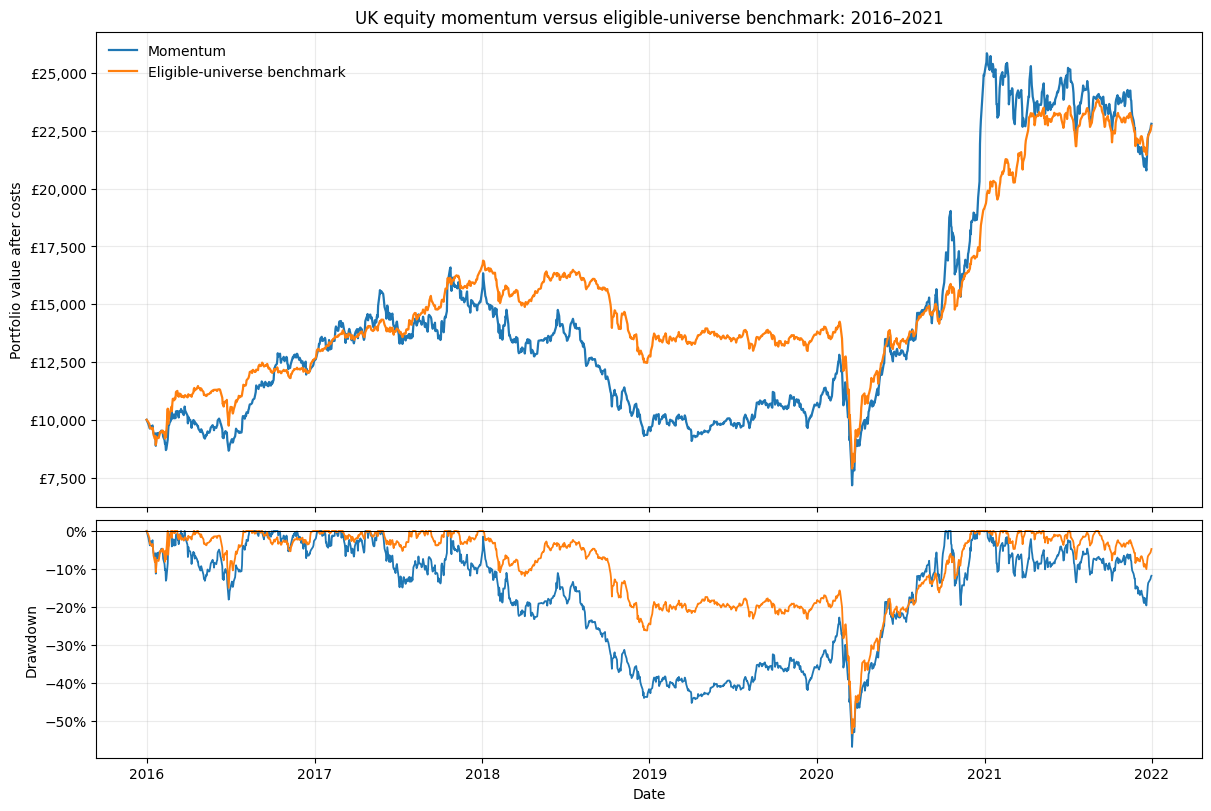

In [16]:
import momentum_plotting

importlib.reload(momentum_plotting)

first_position = schedule.index.get_loc(development_equity.index[0])

fig, axes = momentum_plotting.plot_equity_and_drawdown(
    development_equity,
    initial_capital_gbp=BASELINE["initial_capital_gbp"],
    start_date=schedule.index[first_position - 1],
    title="UK equity momentum versus eligible-universe benchmark: 2016–2021",
)

In [17]:
from itertools import product

SWEEP = {
    "formation_sessions": [126, 189, 252],
    "skip_sessions": [0, 21],
    "top_frac": [0.10, 0.20, 0.30],
}

parameter_grid = pd.DataFrame(
    product(
        SWEEP["formation_sessions"],
        SWEEP["skip_sessions"],
        SWEEP["top_frac"],
    ),
    columns=["formation_sessions", "skip_sessions", "top_frac"],
).rename_axis("configuration_id")

baseline_mask = (
    parameter_grid["formation_sessions"].eq(
        BASELINE["formation_sessions"]
    )
    & parameter_grid["skip_sessions"].eq(
        BASELINE["skip_sessions"]
    )
    & parameter_grid["top_frac"].eq(BASELINE["top_frac"])
)

assert baseline_mask.sum() == 1

baseline_configuration_id = int(
    parameter_grid.index[baseline_mask][0]
)

print(f"Configurations: {len(parameter_grid)}")
print(f"Baseline configuration: {baseline_configuration_id}")
display(parameter_grid)

Configurations: 18
Baseline configuration: 16


,formation_sessions,skip_sessions,top_frac
configuration_id,,,
0,126,0,0.1
1,126,0,0.2
2,126,0,0.3
3,126,21,0.1
4,126,21,0.2
5,126,21,0.3
6,189,0,0.1
7,189,0,0.2
8,189,0,0.3


In [18]:
importlib.reload(momentum_features)

# Retain warm-up history, stopping at the development period's end.
sweep_end = development_dates[-1]

sweep_features, sweep_common_eligible = (
    momentum_features.build_momentum_sweep_features(
        prices=prices.loc[:sweep_end],
        schedule=schedule.loc[:sweep_end],
        liquidity=liquidity.loc[:sweep_end],
        parameter_grid=parameter_grid,
    )
)

# Inspect availability on the actual monthly signal dates.
sweep_eligible_counts = (
    sweep_common_eligible
    .groupby(level="Date")
    .sum()
    .loc[development_rebalances.index]
)

print(f"Distinct momentum feature panels: {len(sweep_features)}")

display(
    sweep_eligible_counts.describe().to_frame(
        "Common eligible stocks at monthly signals"
    )
)

Distinct momentum feature panels: 6


,Common eligible stocks at monthly signals
count,72.000000
mean,95.541667
std,37.739633
min,48.000000
25%,70.000000
50%,88.500000
75%,111.000000
max,194.000000


In [19]:
import momentum_sweep

importlib.reload(momentum_sweep)

sweep_results = momentum_sweep.run_momentum_sweep(
    market=market,
    feature_panels=sweep_features,
    parameter_grid=parameter_grid,
    rebalance_calendar=development_rebalances,
    sessions=development_dates,
    initial_capital_gbp=BASELINE["initial_capital_gbp"],
    cost_per_side_bps=EXECUTION["cost_per_side_bps"],
    max_missing_valuation_sessions=EXECUTION[
        "max_missing_valuation_sessions"
    ],
)

sweep_equity = pd.DataFrame({
    configuration_id: result["daily"]["equity_gbp"]
    for configuration_id, result in sweep_results["backtests"].items()
}).rename_axis(columns="configuration_id")

sweep_benchmark_daily = sweep_results["benchmark"]["daily"]

print(f"Completed configurations: {sweep_equity.shape[1]}")
print(f"Development sessions: {sweep_equity.shape[0]}")

Running shared benchmark...
Running configuration 0 (1/18)...
Running configuration 1 (2/18)...
Running configuration 2 (3/18)...
Running configuration 3 (4/18)...
Running configuration 4 (5/18)...
Running configuration 5 (6/18)...
Running configuration 6 (7/18)...
Running configuration 7 (8/18)...
Running configuration 8 (9/18)...
Running configuration 9 (10/18)...
Running configuration 10 (11/18)...
Running configuration 11 (12/18)...
Running configuration 12 (13/18)...
Running configuration 13 (14/18)...
Running configuration 14 (15/18)...
Running configuration 15 (16/18)...
Running configuration 16 (17/18)...
Running configuration 17 (18/18)...
Completed configurations: 18
Development sessions: 1518


In [20]:
importlib.reload(momentum_sweep)

assert all(
    result["daily"].index.equals(sweep_benchmark_daily.index)
    for result in sweep_results["backtests"].values()
)

sweep_benchmark_summary = momentum_sweep.summarise_momentum_backtest(
    sweep_benchmark_daily,
    initial_capital_gbp=BASELINE["initial_capital_gbp"],
)

sweep_metrics = pd.DataFrame({
    configuration_id: momentum_sweep.summarise_momentum_backtest(
        result["daily"],
        initial_capital_gbp=BASELINE["initial_capital_gbp"],
    )
    for configuration_id, result in sweep_results["backtests"].items()
}).T.rename_axis("configuration_id")

sweep_metrics.insert(
    2,
    "cagr_gap_pp",
    sweep_metrics["net_cagr_pct"]
    - sweep_benchmark_summary["net_cagr_pct"],
)

sweep_summary = sweep_results["parameter_grid"].join(
    sweep_metrics,
    validate="one_to_one",
)

display(sweep_benchmark_summary.round(2).to_frame("Benchmark"))
display(sweep_summary.round(2))

,Benchmark
final_equity_gbp,22717.49
net_cagr_pct,14.59
volatility_pct,18.10
sharpe_zero_rf,0.84
max_drawdown_pct,-53.26
annual_two_way_turnover,3.55
total_cost_gbp,315.37
mean_cash_pct,0.07


,formation_sessions,skip_sessions,top_frac,final_equity_gbp,net_cagr_pct,cagr_gap_pp,volatility_pct,sharpe_zero_rf,max_drawdown_pct,annual_two_way_turnover,total_cost_gbp,mean_cash_pct
configuration_id,,,,,,,,,,,,
0,126,0,0.1,8483.35,-2.69,-17.29,37.17,0.11,-74.66,10.33,577.82,0.01
1,126,0,0.2,17463.37,9.70,-4.90,26.02,0.49,-64.36,9.32,711.61,0.05
2,126,0,0.3,22386.17,14.31,-0.28,22.15,0.72,-55.59,8.28,740.14,0.06
3,126,21,0.1,11440.18,2.26,-12.33,36.41,0.24,-70.88,10.60,651.06,0.08
4,126,21,0.2,10689.50,1.11,-13.48,25.63,0.17,-68.38,10.08,626.65,0.07
5,126,21,0.3,17940.64,10.19,-4.40,21.89,0.55,-59.92,9.20,666.68,0.07
6,189,0,0.1,25043.87,16.46,1.87,35.18,0.61,-51.03,9.08,1010.14,0.01
7,189,0,0.2,21062.00,13.16,-1.43,25.81,0.61,-51.92,8.31,815.90,0.06
8,189,0,0.3,20423.54,12.59,-2.01,22.27,0.64,-55.98,7.65,691.19,0.05


In [21]:
importlib.reload(momentum_sweep)

annual_strategy_pct = (
    pd.DataFrame({
        configuration_id: momentum_sweep.annual_net_returns(
            result["daily"]
        )
        for configuration_id, result
        in sweep_results["backtests"].items()
    })
    .T
    .mul(100)
    .rename_axis(index="configuration_id", columns="year")
)

annual_benchmark_pct = (
    momentum_sweep.annual_net_returns(sweep_benchmark_daily)
    .mul(100)
)

# Difference between the two compounded annual returns.
annual_gap_pp = annual_strategy_pct.sub(
    annual_benchmark_pct,
    axis="columns",
)

annual_comparison = sweep_results["parameter_grid"].join(
    annual_gap_pp,
    validate="one_to_one",
)

display(
    annual_benchmark_pct.round(2).to_frame("Benchmark return %")
)
display(annual_comparison.round(2))

,Benchmark return %
year,
2016,26.17
2017,30.76
2018,-22.54
2019,7.12
2020,39.65
2021,18.84


,formation_sessions,skip_sessions,top_frac,2016,2017,2018,2019,2020,2021
configuration_id,,,,,,,,,
0,126,0,0.1,-21.56,2.15,-33.56,-17.67,112.99,-57.33
1,126,0,0.2,-12.67,9.10,-19.40,-11.58,113.76,-40.58
2,126,0,0.3,-13.25,15.69,-6.81,-1.79,60.26,-27.84
3,126,21,0.1,-4.10,-22.60,-18.41,-28.33,137.83,-51.72
4,126,21,0.2,-5.97,-18.64,-17.57,-16.36,48.45,-41.26
5,126,21,0.3,-17.87,-3.55,-11.48,-4.96,38.75,-10.53
6,189,0,0.1,10.88,28.62,-19.13,14.35,120.31,-56.59
7,189,0,0.2,7.51,12.13,-13.22,8.16,58.11,-43.55
8,189,0,0.3,2.73,4.22,-7.32,-1.41,39.53,-30.48


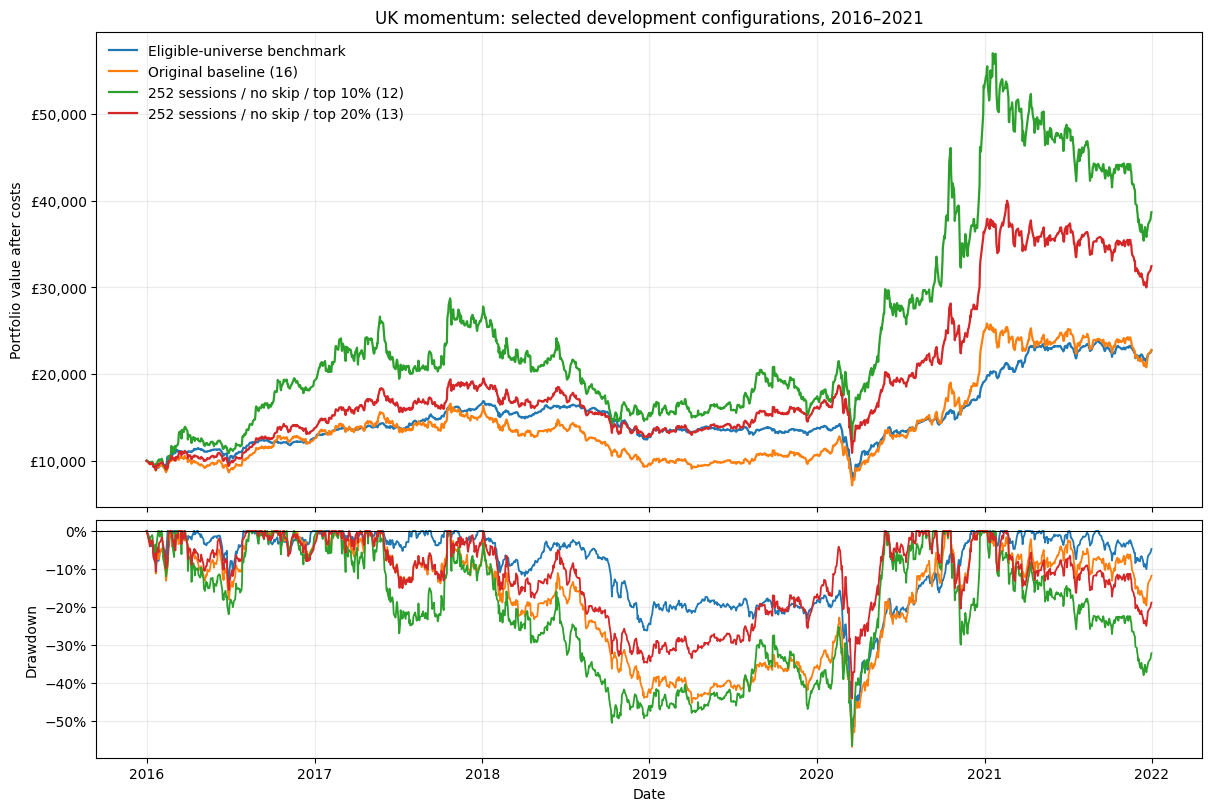

In [22]:
sweep_comparison_equity = pd.DataFrame({
    "Eligible-universe benchmark": (
        sweep_benchmark_daily["equity_gbp"]
    ),
    f"Original baseline ({baseline_configuration_id})": (
        sweep_equity[baseline_configuration_id]
    ),
    "252 sessions / no skip / top 10% (12)": sweep_equity[12],
    "252 sessions / no skip / top 20% (13)": sweep_equity[13],
})

sweep_start_position = schedule.index.get_loc(
    sweep_comparison_equity.index[0]
)

fig, axes = momentum_plotting.plot_equity_and_drawdown(
    sweep_comparison_equity,
    initial_capital_gbp=BASELINE["initial_capital_gbp"],
    start_date=schedule.index[sweep_start_position - 1],
    title="UK momentum: selected development configurations, 2016–2021",
)

In [23]:
import numpy as np

INFERENCE = {
    "primary_block_length": 63,
    "sensitivity_block_lengths": [21, 126],
    "n_bootstrap": 10_000,
    "alpha": 0.05,
    "seed": 42,
}

sweep_net_returns = pd.DataFrame({
    configuration_id: result["daily"]["net_return"]
    for configuration_id, result
    in sweep_results["backtests"].items()
}).rename_axis(index="Date", columns="configuration_id")

if not sweep_net_returns.index.equals(sweep_benchmark_daily.index):
    raise ValueError("Strategy and benchmark dates must match.")

if not sweep_net_returns.columns.equals(
    sweep_results["parameter_grid"].index
):
    raise ValueError("Every configuration must be included.")

sweep_excess_returns = sweep_net_returns.sub(
    sweep_benchmark_daily["net_return"],
    axis="index",
)

if not np.isfinite(sweep_excess_returns.to_numpy()).all():
    raise ValueError("Excess returns contain missing or invalid values.")

print(f"Sessions: {len(sweep_excess_returns)}")
print(f"Configurations: {sweep_excess_returns.shape[1]}")

display(
    sweep_excess_returns.mean()
    .mul(10_000)
    .to_frame("mean_daily_net_excess_bps")
    .round(3)
)

Sessions: 1518
Configurations: 18


,mean_daily_net_excess_bps
configuration_id,
0,-4.422
1,-1.043
2,0.228
3,-2.554
4,-4.313
5,-1.253
6,2.445
7,0.176
8,-0.364


In [26]:
import momentum_validation

importlib.reload(momentum_validation)

primary_inference = momentum_validation.bootstrap_sweep_excess(
    sweep_excess_returns,
    block_length=INFERENCE["primary_block_length"],
    n_bootstrap=INFERENCE["n_bootstrap"],
    alpha=INFERENCE["alpha"],
    seed=INFERENCE["seed"],
)

primary_inference_table = sweep_results["parameter_grid"].join(
    primary_inference,
    validate="one_to_one",
)

display(
    primary_inference_table
    .sort_values("p_one_sided")
    .round(4)
)

print(
    "Configurations passing Holm correction: "
    f"{int(primary_inference['reject_holm'].sum())}"
    f"/{len(primary_inference)}"
)

,formation_sessions,skip_sessions,top_frac,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,p_holm,reject_holm
configuration_id,,,,,,,,,
12,252,0,0.1,5.4806,-3.9813,14.6317,0.1221,1.0,False
13,252,0,0.2,3.0291,-2.2907,8.2006,0.1276,1.0,False
6,189,0,0.1,2.4450,-8.0446,12.7894,0.3188,1.0,False
15,252,21,0.1,1.8066,-7.5116,11.0481,0.3507,1.0,False
16,252,21,0.2,0.7278,-4.6090,5.9167,0.3911,1.0,False
17,252,21,0.3,0.5477,-3.6945,4.8666,0.4037,1.0,False
14,252,0,0.3,0.2103,-3.8678,4.3151,0.4627,1.0,False
2,126,0,0.3,0.2277,-4.4082,5.0160,0.4709,1.0,False
7,189,0,0.2,0.1762,-5.9510,6.5690,0.4867,1.0,False


Configurations passing Holm correction: 0/18


In [27]:
block_results = {
    INFERENCE["primary_block_length"]: primary_inference,
}

for block_length in INFERENCE["sensitivity_block_lengths"]:
    block_results[block_length] = (
        momentum_validation.bootstrap_sweep_excess(
            sweep_excess_returns,
            block_length=block_length,
            n_bootstrap=INFERENCE["n_bootstrap"],
            alpha=INFERENCE["alpha"],
            seed=INFERENCE["seed"],
        )
    )

inference_sensitivity = pd.concat(
    block_results,
    names=["block_length", "configuration_id"],
).sort_index()

# Count results across all 18 configurations for each block length.
sensitivity_counts = (
    inference_sensitivity.assign(
        reject_uncorrected=lambda table: (
            table["mean_daily_net_excess_bps"].gt(0)
            & table["p_one_sided"].le(INFERENCE["alpha"])
        )
    )
    .groupby(level="block_length")
    .agg(
        configurations=("p_one_sided", "size"),
        uncorrected_passes=("reject_uncorrected", "sum"),
        holm_passes=("reject_holm", "sum"),
    )
)

display(sensitivity_counts)

# Inspect the two leading candidates and the original baseline.
focus = (
    inference_sensitivity.index
    .get_level_values("configuration_id")
    .isin([12, 13, baseline_configuration_id])
)

display(inference_sensitivity.loc[focus].round(4))

,configurations,uncorrected_passes,holm_passes
block_length,,,
21,18,0,0
63,18,0,0
126,18,0,0


mean_daily_net_excess_bps  lower_ci_bps  \
block_length configuration_id                                            
21           12                                   5.4806       -4.2617   
             13                                   3.0291       -2.7749   
             16                                   0.7278       -4.8546   
63           12                                   5.4806       -3.9813   
             13                                   3.0291       -2.2907   
             16                                   0.7278       -4.6090   
126          12                                   5.4806       -3.5455   
             13                                   3.0291       -2.1806   
             16                                   0.7278       -4.8211   

                               upper_ci_bps  p_one_sided  p_holm  reject_holm  
block_length configuration_id                                                  
21           12                     14.7647       0.1314     1.0        False  
             13                      8.6642       0.1476     1.0        False  
             16                      6.1201       0.3906     1.0        False  
63           12                     14.6317       0.1221     1.0        False  
             13                      8.2006       0.1276     1.0        False  
             16                      5.9167       0.3911     1.0        False  
126          12                     14.4574       0.1225     1.0        False  
             13                      8.1583       0.1310     1.0        False  
             16                      6.0072       0.3960     1.0        False

In [29]:
import momentum_walk_forward

importlib.reload(momentum_walk_forward)

WALK_FORWARD = {
    "training_years": 3,
    "selection_metric": "sharpe_zero_rf",
    "refit_frequency": "annual",
    "tie_break": "lowest_configuration_id",
}

walk_forward_folds = (
    momentum_walk_forward.build_annual_walk_forward_folds(
        net_returns=sweep_net_returns,
        schedule=schedule,
        training_years=WALK_FORWARD["training_years"],
    )
)

display(walk_forward_folds)

,train_start,train_end,selection_date,test_start,test_end,train_sessions,test_sessions
fold,,,,,,,
0,2016-01-04,2018-12-31,2018-12-31,2019-01-02,2019-12-31,758,253
1,2017-01-03,2019-12-31,2019-12-31,2020-01-02,2020-12-31,758,254
2,2018-01-02,2020-12-31,2020-12-31,2021-01-04,2021-12-31,760,253


In [30]:
importlib.reload(momentum_walk_forward)

walk_forward_choices = (
    momentum_walk_forward.select_walk_forward_configurations(
        net_returns=sweep_net_returns,
        folds=walk_forward_folds,
        parameter_grid=sweep_results["parameter_grid"],
        rules=WALK_FORWARD,
    )
)

display(
    walk_forward_choices[[
        "train_start",
        "train_end",
        "test_start",
        "configuration_id",
        "formation_sessions",
        "skip_sessions",
        "top_frac",
        "training_sharpe",
    ]].round(3)
)

,train_start,train_end,test_start,configuration_id,formation_sessions,skip_sessions,top_frac,training_sharpe
fold,,,,,,,,
0,2016-01-04,2018-12-31,2019-01-02,12,252,0,0.1,0.597
1,2017-01-03,2019-12-31,2020-01-02,11,189,21,0.3,0.371
2,2018-01-02,2020-12-31,2021-01-04,13,252,0,0.2,0.916


In [31]:
importlib.reload(momentum_walk_forward)

walk_forward_targets, walk_forward_decisions = (
    momentum_walk_forward.build_walk_forward_targets(
        choices=walk_forward_choices,
        sweep_results=sweep_results,
    )
)

print(f"Monthly target rows: {len(walk_forward_targets)}")

display(
    walk_forward_decisions
    .groupby(["fold", "configuration_id"])
    .size()
    .rename("monthly_rebalances")
    .to_frame()
)

Monthly target rows: 36


,,monthly_rebalances
fold,configuration_id,
0,12,12
1,11,12
2,13,12


In [32]:
walk_forward_dates = schedule.index[
    (schedule.index >= walk_forward_choices["test_start"].min())
    & (schedule.index <= walk_forward_choices["test_end"].max())
]

walk_forward_benchmark_targets = (
    sweep_results["benchmark"]["targets"]
    .loc[walk_forward_targets.index]
    .copy()
)

target_sets = {
    "Walk-forward": walk_forward_targets,
    "Benchmark": walk_forward_benchmark_targets,
}

walk_forward_backtests = {}

for name, targets in target_sets.items():
    print(f"Running {name}...", flush=True)

    walk_forward_backtests[name] = (
        momentum_backtest.run_momentum_backtest(
            market=market,
            targets=targets,
            sessions=walk_forward_dates,
            initial_capital_gbp=BASELINE["initial_capital_gbp"],
            cost_per_side_bps=EXECUTION["cost_per_side_bps"],
            max_missing_valuation_sessions=EXECUTION[
                "max_missing_valuation_sessions"
            ],
        )
    )

walk_forward_daily = walk_forward_backtests["Walk-forward"]["daily"]
walk_forward_benchmark_daily = walk_forward_backtests["Benchmark"]["daily"]

walk_forward_equity = pd.DataFrame({
    name: result["daily"]["equity_gbp"]
    for name, result in walk_forward_backtests.items()
})

walk_forward_summary = pd.DataFrame({
    name: momentum_sweep.summarise_momentum_backtest(
        result["daily"],
        initial_capital_gbp=BASELINE["initial_capital_gbp"],
    )
    for name, result in walk_forward_backtests.items()
}).T.rename_axis("portfolio")

print(f"Sessions per portfolio: {len(walk_forward_dates)}")
display(walk_forward_summary.round(2))

Running Walk-forward...
Running Benchmark...
Sessions per portfolio: 760


,final_equity_gbp,net_cagr_pct,volatility_pct,sharpe_zero_rf,max_drawdown_pct,annual_two_way_turnover,total_cost_gbp,mean_cash_pct
portfolio,,,,,,,,
Walk-forward,16391.45,17.80,30.70,0.69,-50.74,8.43,336.95,0.08
Benchmark,17806.17,21.08,20.52,1.04,-44.58,3.43,129.08,0.07


In [33]:
walk_forward_annual = pd.DataFrame({
    name: momentum_sweep.annual_net_returns(result["daily"])
    for name, result in walk_forward_backtests.items()
}).mul(100)

walk_forward_annual["gap_pp"] = (
    walk_forward_annual["Walk-forward"]
    - walk_forward_annual["Benchmark"]
)

display(walk_forward_annual.round(2))

,Walk-forward,Benchmark,gap_pp
year,,,
2019,11.19,7.29,3.89
2020,65.57,39.65,25.92
2021,-10.96,18.84,-29.80


In [34]:
validation_protocol = {
    "signal": "raw_momentum_score",
    "parameter_grid": (
        parameter_grid.reset_index().to_dict(orient="records")
    ),
    "walk_forward": WALK_FORWARD.copy(),
    "liquidity": LIQUIDITY.copy(),
    "execution": EXECUTION.copy(),
    "rebalance_frequency": BASELINE["rebalance_frequency"],
    "initial_capital_gbp": BASELINE["initial_capital_gbp"],
    "initial_state": "cash",
    "carry_holdings_across_years": True,
    "cash_interest_annual": 0.0,
    "eligibility": "common across all momentum configurations",
    "benchmark": "monthly equal weight across common eligible stocks",
    "validation": PERIODS["validation"].copy(),
    "reserved_holdout": PERIODS["holdout"].copy(),
    "primary_test": "mean daily net excess over benchmark > 0",
    "inference": INFERENCE.copy(),
}

validation_protocol_path = (
    PROJECT_DIR / "data" / "raw_momentum_validation_protocol_v1.json"
)

if validation_protocol_path.exists():
    saved_protocol = json.loads(validation_protocol_path.read_text())

    if saved_protocol != validation_protocol:
        raise ValueError(
            "Settings differ from the saved validation protocol."
        )
else:
    validation_protocol_path.write_text(
        json.dumps(validation_protocol, indent=2, sort_keys=True) + "\n"
    )

VALIDATION_PROTOCOL = json.loads(
    validation_protocol_path.read_text()
)

print("Validation rules frozen.")
print("Period: 2022–2023; 2024–2025 remains reserved.")
print("Both portfolios start with £10,000 cash.")
print("Holdings carry continuously from 2022 into 2023.")

Validation rules frozen.
Period: 2022–2023; 2024–2025 remains reserved.
Both portfolios start with £10,000 cash.
Holdings carry continuously from 2022 into 2023.


In [35]:
validation_bounds = VALIDATION_PROTOCOL["validation"]

validation_dates = schedule.index[
    (schedule.index >= validation_bounds["start"])
    & (schedule.index < validation_bounds["end_exclusive"])
]

validation_parameter_grid = pd.DataFrame(
    VALIDATION_PROTOCOL["parameter_grid"]
).set_index("configuration_id")

if LIQUIDITY != VALIDATION_PROTOCOL["liquidity"]:
    raise ValueError("Liquidity settings differ from the frozen rules.")

# Keep historical observations for rolling features and training.
validation_end = validation_dates[-1]

validation_features, validation_common_eligible = (
    momentum_features.build_momentum_sweep_features(
        prices=prices.loc[:validation_end],
        schedule=schedule.loc[:validation_end],
        liquidity=liquidity.loc[:validation_end],
        parameter_grid=validation_parameter_grid,
    )
)

# Adding later observations must not change earlier signals.
for key, development_panel in sweep_features.items():
    pd.testing.assert_frame_equal(
        validation_features[key].loc[development_panel.index],
        development_panel,
    )

# Select by execution date: January's signal comes from December.
validation_rebalances = rebalance_calendar.loc[
    rebalance_calendar["execution_date"].ge(
        validation_bounds["start"]
    )
    & rebalance_calendar["execution_date"].lt(
        validation_bounds["end_exclusive"]
    )
].copy()

validation_eligible_counts = (
    validation_common_eligible
    .groupby(level="Date")
    .sum()
    .loc[validation_rebalances.index]
    .rename("eligible_stocks")
)

print(f"Feature panels: {len(validation_features)}")
print(f"Validation sessions: {len(validation_dates)}")
print(f"Monthly rebalances: {len(validation_rebalances)}")
print("Development signals unchanged.")

display(
    validation_rebalances.join(validation_eligible_counts).head()
)

Feature panels: 6
Validation sessions: 501
Monthly rebalances: 24
Development signals unchanged.


,execution_date,eligible_stocks
signal_date,,
2021-12-31,2022-01-04,141
2022-01-31,2022-02-01,143
2022-02-28,2022-03-01,148
2022-03-31,2022-04-01,163
2022-04-29,2022-05-03,159


In [36]:
validation_history_dates = development_dates.append(
    validation_dates
)

validation_history_rebalances = pd.concat([
    development_rebalances,
    validation_rebalances,
]).sort_index()

validation_sweep_results = momentum_sweep.run_momentum_sweep(
    market=market.loc[:validation_end],
    feature_panels=validation_features,
    parameter_grid=validation_parameter_grid,
    rebalance_calendar=validation_history_rebalances,
    sessions=validation_history_dates,
    initial_capital_gbp=VALIDATION_PROTOCOL["initial_capital_gbp"],
    cost_per_side_bps=VALIDATION_PROTOCOL["execution"][
        "cost_per_side_bps"
    ],
    max_missing_valuation_sessions=VALIDATION_PROTOCOL["execution"][
        "max_missing_valuation_sessions"
    ],
)

validation_candidate_returns = pd.DataFrame({
    configuration_id: result["daily"]["net_return"]
    for configuration_id, result
    in validation_sweep_results["backtests"].items()
}).rename_axis(index="Date", columns="configuration_id")

# Extending the replay must reproduce the development returns.
pd.testing.assert_frame_equal(
    validation_candidate_returns.loc[sweep_net_returns.index],
    sweep_net_returns,
)

pd.testing.assert_series_equal(
    validation_sweep_results["benchmark"]["daily"].loc[
        sweep_benchmark_daily.index, "net_return"
    ],
    sweep_benchmark_daily["net_return"],
)

print(
    f"Candidate configurations: "
    f"{validation_candidate_returns.shape[1]}"
)
print(
    f"Historical sessions: "
    f"{len(validation_candidate_returns):,}"
)
print("Development strategy and benchmark returns reproduced.")

Running shared benchmark...
Running configuration 0 (1/18)...
Running configuration 1 (2/18)...
Running configuration 2 (3/18)...
Running configuration 3 (4/18)...
Running configuration 4 (5/18)...
Running configuration 5 (6/18)...
Running configuration 6 (7/18)...
Running configuration 7 (8/18)...
Running configuration 8 (9/18)...
Running configuration 9 (10/18)...
Running configuration 10 (11/18)...
Running configuration 11 (12/18)...
Running configuration 12 (13/18)...
Running configuration 13 (14/18)...
Running configuration 14 (15/18)...
Running configuration 15 (16/18)...
Running configuration 16 (17/18)...
Running configuration 17 (18/18)...
Candidate configurations: 18
Historical sessions: 2,019
Development strategy and benchmark returns reproduced.


In [37]:
validation_folds = (
    momentum_walk_forward.build_annual_walk_forward_folds(
        net_returns=validation_candidate_returns,
        schedule=schedule.loc[:validation_end],
        training_years=VALIDATION_PROTOCOL["walk_forward"][
            "training_years"
        ],
    )
)

validation_folds = validation_folds.loc[
    validation_folds["test_start"].ge(validation_bounds["start"])
    & validation_folds["test_end"].lt(
        validation_bounds["end_exclusive"]
    )
].copy()

assert validation_folds["test_start"].dt.year.tolist() == [2022, 2023]

validation_choices = (
    momentum_walk_forward.select_walk_forward_configurations(
        net_returns=validation_candidate_returns.loc[
            :validation_folds["train_end"].max()
        ],
        folds=validation_folds,
        parameter_grid=validation_parameter_grid,
        rules=VALIDATION_PROTOCOL["walk_forward"],
    )
)

display(
    validation_choices[[
        "train_start",
        "train_end",
        "test_start",
        "configuration_id",
        "formation_sessions",
        "skip_sessions",
        "top_frac",
        "training_sharpe",
    ]].round(3)
)

,train_start,train_end,test_start,configuration_id,formation_sessions,skip_sessions,top_frac,training_sharpe
fold,,,,,,,,
3,2019-01-02,2021-12-31,2022-01-04,13,252,0,0.2,1.203
4,2020-01-02,2022-12-30,2023-01-03,15,252,21,0.1,0.840


In [38]:
validation_targets, validation_decisions = (
    momentum_walk_forward.build_walk_forward_targets(
        choices=validation_choices,
        sweep_results=validation_sweep_results,
    )
)

assert validation_targets.index.equals(
    pd.DatetimeIndex(
        validation_rebalances["execution_date"],
        name="Date",
    )
)

validation_benchmark_targets = (
    validation_sweep_results["benchmark"]["targets"]
    .loc[validation_targets.index]
    .copy()
)

validation_target_sets = {
    "Walk-forward": validation_targets,
    "Benchmark": validation_benchmark_targets,
}

validation_backtests = {}

for name, targets in validation_target_sets.items():
    print(f"Running validation: {name}...", flush=True)

    validation_backtests[name] = (
        momentum_backtest.run_momentum_backtest(
            market=market.loc[validation_dates[0]:validation_end],
            targets=targets,
            sessions=validation_dates,
            initial_capital_gbp=VALIDATION_PROTOCOL[
                "initial_capital_gbp"
            ],
            **VALIDATION_PROTOCOL["execution"],
        )
    )

validation_daily = validation_backtests["Walk-forward"]["daily"]
validation_benchmark_daily = validation_backtests["Benchmark"]["daily"]

validation_equity = pd.DataFrame({
    name: result["daily"]["equity_gbp"]
    for name, result in validation_backtests.items()
})

validation_summary = pd.DataFrame({
    name: momentum_sweep.summarise_momentum_backtest(
        result["daily"],
        initial_capital_gbp=VALIDATION_PROTOCOL[
            "initial_capital_gbp"
        ],
    )
    for name, result in validation_backtests.items()
}).T.rename_axis("portfolio")

print(f"Validation sessions: {len(validation_daily)}")
print(f"Monthly rebalances: {len(validation_targets)}")
display(validation_summary.round(2))

Running validation: Walk-forward...
Running validation: Benchmark...
Validation sessions: 501
Monthly rebalances: 24


,final_equity_gbp,net_cagr_pct,volatility_pct,sharpe_zero_rf,max_drawdown_pct,annual_two_way_turnover,total_cost_gbp,mean_cash_pct
portfolio,,,,,,,,
Walk-forward,8295.28,-8.97,24.69,-0.26,-39.60,8.65,144.61,0.07
Benchmark,6980.66,-16.54,14.90,-1.14,-37.66,3.30,52.09,0.11


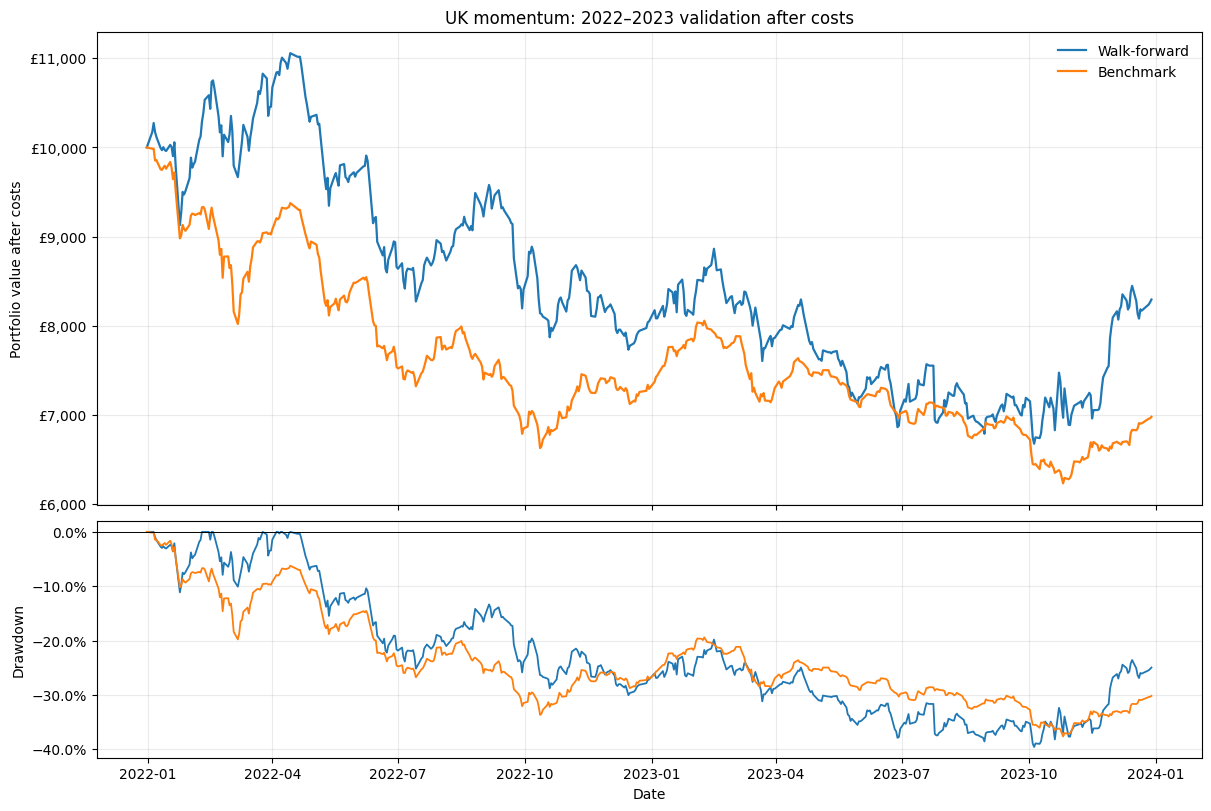

,Walk-forward,Benchmark,gap_pp
year,,,
2022,-19.50,-27.06,7.57
2023,3.04,-4.29,7.33


In [39]:
import momentum_plotting

momentum_plotting.plot_equity_and_drawdown(
    validation_equity,
    initial_capital_gbp=VALIDATION_PROTOCOL["initial_capital_gbp"],
    start_date=schedule.index[
        schedule.index < validation_equity.index[0]
    ][-1],
    title="UK momentum: 2022–2023 validation after costs",
)

validation_annual = pd.DataFrame({
    name: momentum_sweep.annual_net_returns(result["daily"])
    for name, result in validation_backtests.items()
}).mul(100)

validation_annual["gap_pp"] = (
    validation_annual["Walk-forward"]
    - validation_annual["Benchmark"]
)

display(validation_annual.round(2))

In [40]:
import momentum_validation

if not validation_daily.index.equals(
    validation_benchmark_daily.index
):
    raise ValueError("Strategy and benchmark dates must match.")

validation_excess_returns = (
    validation_daily["net_return"]
    - validation_benchmark_daily["net_return"]
).to_frame("Walk-forward")

validation_test_settings = VALIDATION_PROTOCOL["inference"]

validation_inference = (
    momentum_validation.bootstrap_sweep_excess(
        validation_excess_returns,
        block_length=validation_test_settings["primary_block_length"],
        n_bootstrap=validation_test_settings["n_bootstrap"],
        alpha=validation_test_settings["alpha"],
        seed=validation_test_settings["seed"],
    )
    .rename_axis("portfolio")
)

display(
    validation_inference[[
        "mean_daily_net_excess_bps",
        "lower_ci_bps",
        "upper_ci_bps",
        "p_one_sided",
        "reject_holm",
    ]]
    .rename(columns={"reject_holm": "reject_null"})
    .round(4)
)

,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,reject_null
portfolio,,,,,
Walk-forward,4.2128,-5.9791,13.9391,0.2128,False


In [41]:
validation_block_results = {
    validation_test_settings["primary_block_length"]:
        validation_inference.copy()
}

for block_length in validation_test_settings[
    "sensitivity_block_lengths"
]:
    validation_block_results[block_length] = (
        momentum_validation.bootstrap_sweep_excess(
            validation_excess_returns,
            block_length=block_length,
            n_bootstrap=validation_test_settings["n_bootstrap"],
            alpha=validation_test_settings["alpha"],
            seed=validation_test_settings["seed"],
        )
        .rename_axis("portfolio")
    )

validation_sensitivity = pd.concat(
    validation_block_results,
    names=["block_length"],
).sort_index()

display(
    validation_sensitivity[[
        "mean_daily_net_excess_bps",
        "lower_ci_bps",
        "upper_ci_bps",
        "p_one_sided",
        "reject_holm",
    ]]
    .rename(columns={"reject_holm": "reject_null"})
    .round(4)
)

,,mean_daily_net_excess_bps,lower_ci_bps,upper_ci_bps,p_one_sided,reject_null
block_length,portfolio,,,,,
21,Walk-forward,4.2128,-5.2645,12.9577,0.1723,False
63,Walk-forward,4.2128,-5.9791,13.9391,0.2128,False
126,Walk-forward,4.2128,-6.7723,13.7972,0.2170,False


In [42]:
holdout_bounds = VALIDATION_PROTOCOL["reserved_holdout"]

holdout_dates = schedule.index[
    (schedule.index >= holdout_bounds["start"])
    & (schedule.index < holdout_bounds["end_exclusive"])
]

holdout_end = holdout_dates[-1]

holdout_features, holdout_common_eligible = (
    momentum_features.build_momentum_sweep_features(
        prices=prices.loc[:holdout_end],
        schedule=schedule.loc[:holdout_end],
        liquidity=liquidity.loc[:holdout_end],
        parameter_grid=validation_parameter_grid,
    )
)

# Extending the history must preserve all earlier signals.
for key, previous_panel in validation_features.items():
    pd.testing.assert_frame_equal(
        holdout_features[key].loc[previous_panel.index],
        previous_panel,
    )

holdout_rebalances = rebalance_calendar.loc[
    rebalance_calendar["execution_date"].ge(
        holdout_bounds["start"]
    )
    & rebalance_calendar["execution_date"].lt(
        holdout_bounds["end_exclusive"]
    )
].copy()

holdout_eligible_counts = (
    holdout_common_eligible
    .groupby(level="Date")
    .sum()
    .loc[holdout_rebalances.index]
    .rename("eligible_stocks")
)

print(f"Feature panels: {len(holdout_features)}")
print(f"Holdout sessions: {len(holdout_dates)}")
print(f"Monthly rebalances: {len(holdout_rebalances)}")
print("Earlier signals unchanged.")

display(
    holdout_rebalances.join(holdout_eligible_counts).head()
)

Feature panels: 6
Holdout sessions: 507
Monthly rebalances: 24
Earlier signals unchanged.


,execution_date,eligible_stocks
signal_date,,
2023-12-29,2024-01-02,109
2024-01-31,2024-02-01,123
2024-02-29,2024-03-01,121
2024-03-28,2024-04-02,129
2024-04-30,2024-05-01,136


In [43]:
holdout_history_dates = validation_history_dates.append(
    holdout_dates
)

holdout_history_rebalances = pd.concat([
    validation_history_rebalances,
    holdout_rebalances,
]).sort_index()

holdout_sweep_results = momentum_sweep.run_momentum_sweep(
    market=market.loc[:holdout_end],
    feature_panels=holdout_features,
    parameter_grid=validation_parameter_grid,
    rebalance_calendar=holdout_history_rebalances,
    sessions=holdout_history_dates,
    initial_capital_gbp=VALIDATION_PROTOCOL["initial_capital_gbp"],
    **VALIDATION_PROTOCOL["execution"],
)

holdout_candidate_returns = pd.DataFrame({
    configuration_id: result["daily"]["net_return"]
    for configuration_id, result
    in holdout_sweep_results["backtests"].items()
}).rename_axis(index="Date", columns="configuration_id")

# Reproduce all candidate returns through 2023.
pd.testing.assert_frame_equal(
    holdout_candidate_returns.loc[validation_candidate_returns.index],
    validation_candidate_returns,
)

pd.testing.assert_series_equal(
    holdout_sweep_results["benchmark"]["daily"]["net_return"].loc[
        validation_history_dates
    ],
    validation_sweep_results["benchmark"]["daily"]["net_return"],
)

print(
    f"Candidate configurations: "
    f"{holdout_candidate_returns.shape[1]}"
)
print(f"Historical sessions: {len(holdout_candidate_returns):,}")
print("Strategy and benchmark returns through 2023 reproduced.")

Running shared benchmark...


ValueError: 2024-08-01: Unusable open_gbp for required holdings: ['WISE.L']